In [2]:
import zarr
import matplotlib.pyplot as plt

In [15]:
spec = zarr.open_group('/home/100/mj8805/scr_mk27/Turbospectrum_NLTE/outputs/zarr/ca_triplet_intensity.zarr')

In [16]:
spec.tree()

/
├── flux (10000, 25001) float32
├── global_index (10000,) int64
├── model_id (10000,) uint64
├── mu_selected (10000,) float32
├── mu_selected_index (10000,) int16
├── param_names (10,) <U32
├── params (10000, 10) float32
├── physics_hash () <U64
├── provenance
│   ├── atmosphere_manifest.json () StringDType()
│   ├── canonical_config.yaml () StringDType()
│   ├── environment.txt () StringDType()
│   ├── linelist_manifest.json () StringDType()
│   ├── software_manifest.json () StringDType()
│   └── synthesis_config.yaml () StringDType()
├── schema_version () <U16
└── wavelength (25001,) float32

/jobfs/161395643.gadi-pbs/ipykernel_852222/3358486451.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


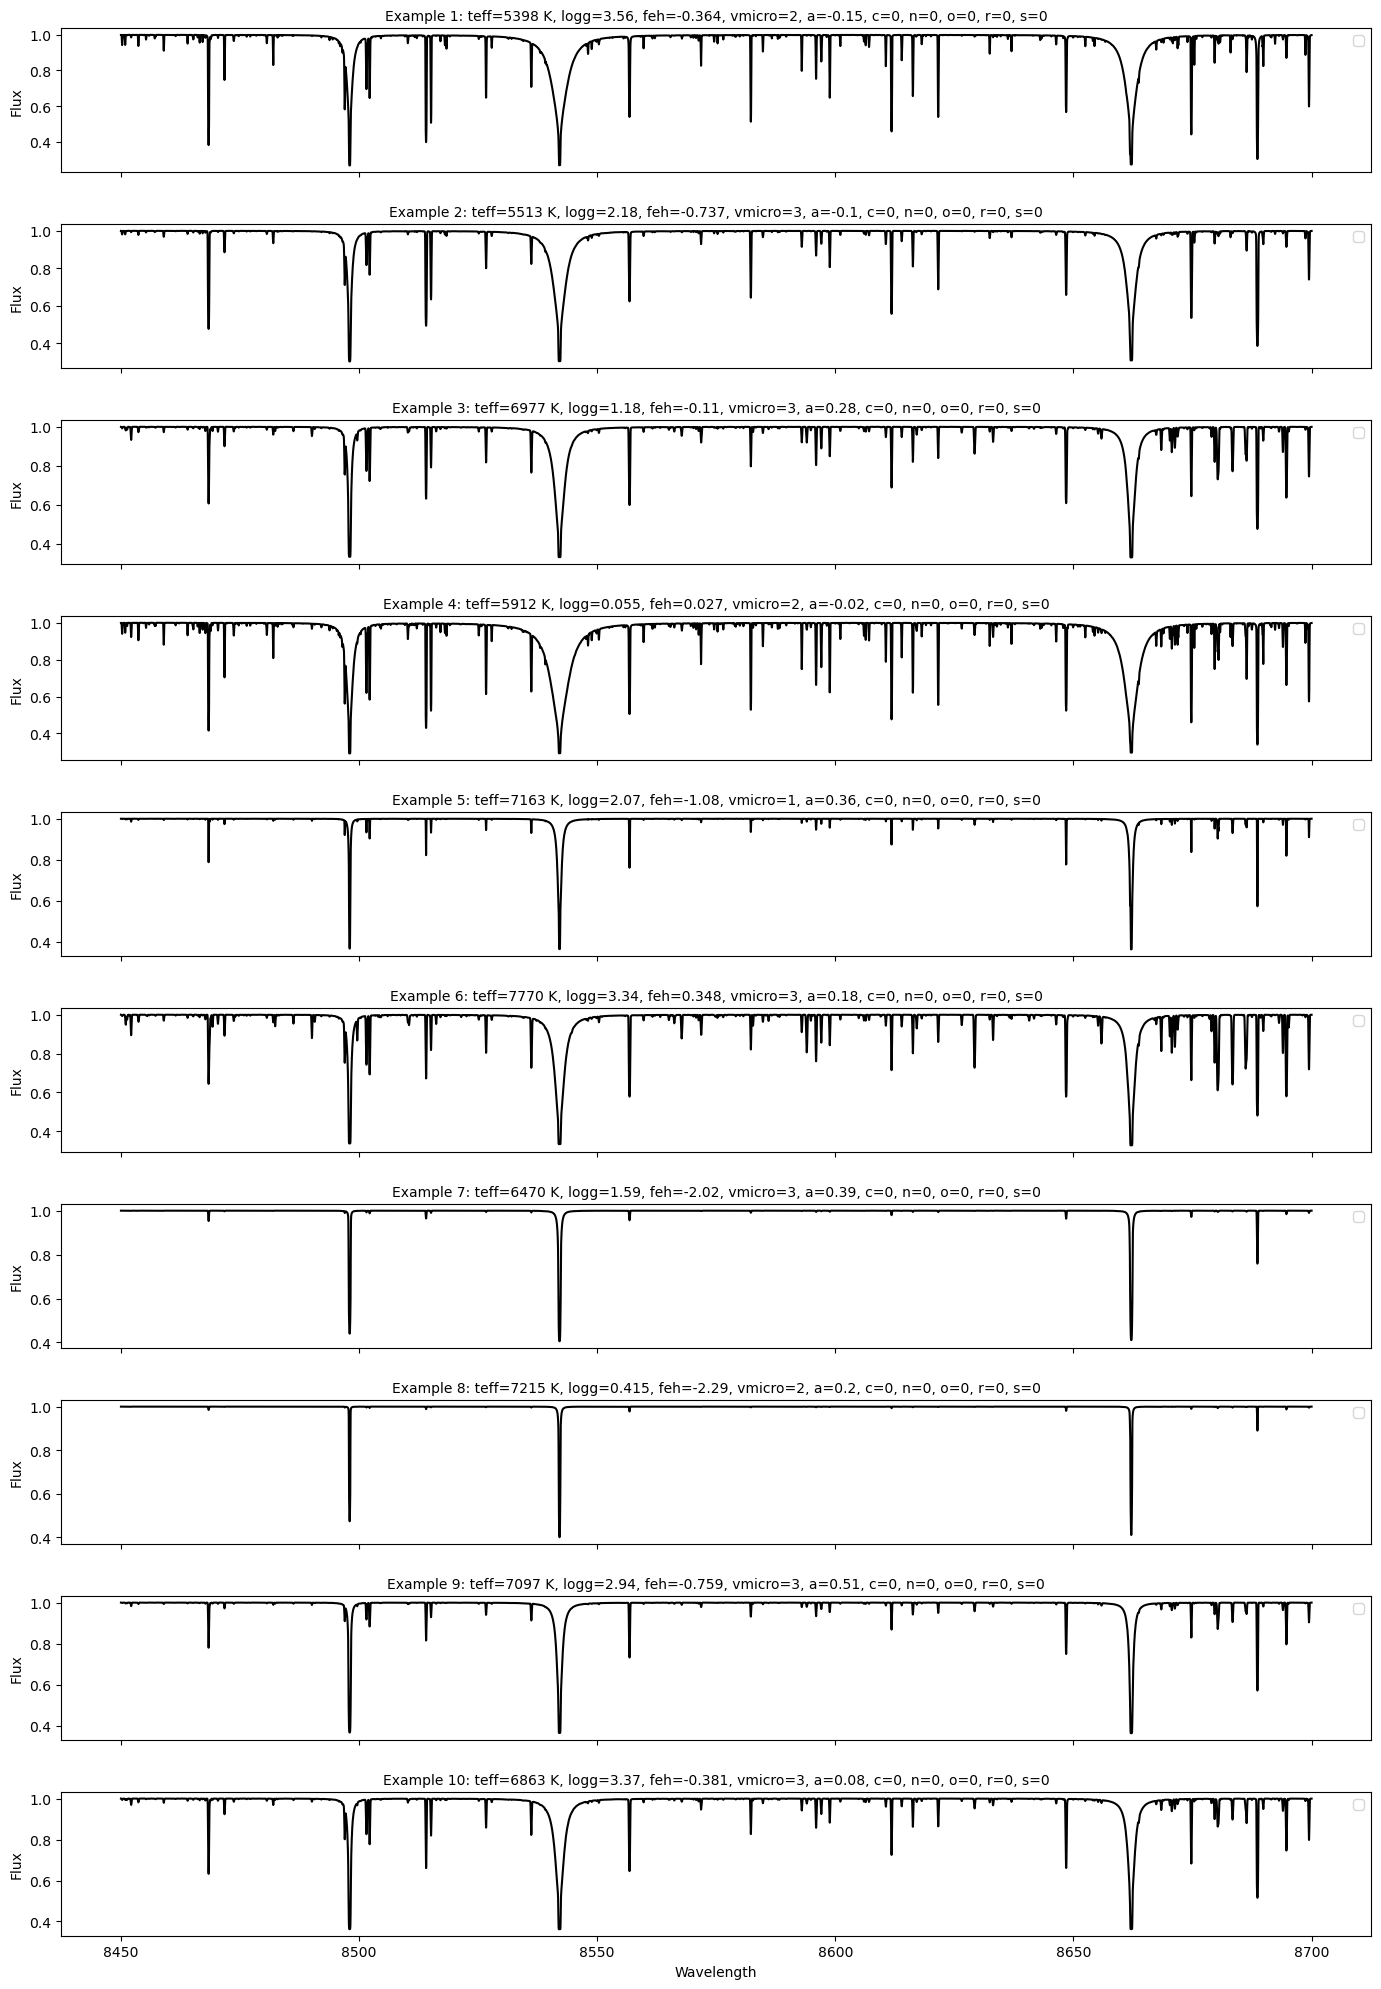

In [23]:
fig, axes = plt.subplots(10, 1, figsize=(14, 20), sharex=True)
wavelengths = spec['wavelength'][()]
params = spec['params'][:10]  # Shape (10, n_params)
param_names = spec['param_names'][()]   # Shape (n_params,); np.str_ type

for i in range(10):
    ax = axes[i]
    ax.plot(wavelengths, spec['flux'][i], color='black')
    param_strs = []
    for name, val in zip(param_names, params[i]):
        if name.lower() == "teff":
            param_strs.append(f"{name}={int(round(val))} K")
        else:
            param_strs.append(f"{name}={val:.3g}")
    ax.set_ylabel('Flux')
    ax.set_title(f'Example {i+1}: ' + ', '.join(param_strs), fontsize=10)
    ax.legend()

axes[-1].set_xlabel('Wavelength')

plt.tight_layout(h_pad=2)
plt.show()